
# Role of the indirect pathway of the basal ganglia in perceptual decision making.
W Wei, JE Rubin, & X-J Wang, JNS 2015.

http://dx.doi.org/10.1523/JNEUROSCI.3611-14.2015

This example also demonstrates how to use Python's cPickle module to save and load
complex data.


In [ ]:

from __future__ import division


import pickle as pkl
import numpy as np

with open('rates.pkl', 'a') as f:
        
        
        

from collections import OrderedDict

import random as pyrand # Import before Brian floods the namespace

from scipy.sparse import csr_matrix

from brian2 import *
from brian2 import mV, nS, ms, kHz




IndentationError: expected an indented block after 'with' statement on line 7 (1827143612.py, line 10)


=========================================================================================
### Equations
=========================================================================================

 sAMPA, x, sNMDA, sGABA are synaptic conductances stored pre-synatically
 S_AMPA, S_NMDA, S_GABA are synaptic conductances stored post-synaptically

In [ ]:


model_equations = {}

model_equations['E'] = '''
    dV/dt         = (-(V - V_L) - Isyn/gE) / tau_m_E : volt
    Isyn          = I_AMPA_ext + I_AMPA + I_NMDA + I_GABA : amp
    I_AMPA_ext    = gAMPA_ext_E*sAMPA_ext*(V - V_E) : amp
    I_AMPA        = gAMPA_E*S_AMPA*(V - V_E) : amp
    I_NMDA        = gNMDA_E*S_NMDA*(V - V_E)/(1 + exp(-a*V)/b) : amp
    I_GABA        = gGABA_E*S_GABA*(V - V_I) : amp
    dsAMPA_ext/dt = -sAMPA_ext/tauAMPA : 1
    dsAMPA/dt     = -sAMPA/tauAMPA : 1
    dsNMDA/dt     = -sNMDA/tauNMDA : 1
    S_AMPA : 1
    S_NMDA : 1
    S_GABA : 1
    '''

model_equations['I'] = '''
    dV/dt         = (-(V - V_L) - Isyn/gI) / tau_m_I : volt
    Isyn          = I_AMPA_ext + I_AMPA + I_NMDA + I_GABA : amp
    I_AMPA_ext    = gAMPA_ext_I*sAMPA_ext*(V - V_E) : amp
    I_AMPA        = gAMPA_I*S_AMPA*(V - V_E) : amp
    I_NMDA        = gNMDA_I*S_NMDA*(V - V_E)/(1 + exp(-a*V)/b) : amp
    I_GABA        = gGABA_I*S_GABA*(V - V_I) : amp
    dsAMPA_ext/dt = -sAMPA_ext/tauAMPA : 1
    dsGABA/dt     = -sGABA/tauGABA : 1
    S_AMPA: 1
    S_NMDA: 1
    S_GABA: 1
    '''

model_equations['Str'] = '''
    dV/dt         = (-(V - V_L) - Isyn/gI) / tau_m_I : volt
    Isyn          = I_AMPA_ext + I_AMPA + I_GABA : amp
    I_AMPA_ext    = gAMPA_ext_I*sAMPA_ext*(V - V_E) : amp
    I_AMPA        = gAMPA_I*S_AMPA*(V - V_E) : amp
    I_GABA        = gGABA_I*S_GABA*(V - V_I) : amp
    dsAMPA_ext/dt = -sAMPA_ext/tauAMPA : 1
    dsGABA/dt     = -sGABA/tauGABA : 1
    S_AMPA: 1
    S_GABA: 1
    '''

model_equations['GPe'] = '''
    dV/dt         = (-(V - V_L) - I_T/gI - Isyn/gI) / tau_m_I : volt
    Isyn          = I_AMPA_ext + I_GABA_ext + I_AMPA + I_NMDA + I_GABA : amp
    I_AMPA_ext    = gAMPA_ext_I*sAMPA_ext*(V - V_E) : amp
    I_GABA_ext    = gGABA_ext_I*sGABA_ext*(V - V_I) : amp
    I_AMPA        = gAMPA_I*S_AMPA*(V - V_E) : amp
    I_NMDA        = gNMDA_I*S_NMDA*(V - V_E)/(1 + exp(-a*V)/b) : amp
    I_GABA        = gGABA_I*S_GABA*(V - V_I) : amp
    T_open        = int(V>V_h):1
    I_T           = gT*h*T_open*(V-V_T) : amp
    dsAMPA_ext/dt = -sAMPA_ext/tauAMPA : 1
    dsGABA_ext/dt = -sGABA_ext/tauGABA : 1
    dsGABA/dt     = -sGABA/tauGABA : 1
    dh/dt         = -h/tauhminus*int(V>=V_h) + (1-h)/tauhplus*int(V<V_h) : 1
    S_AMPA: 1
    S_NMDA: 1
    S_GABA: 1
    '''

model_equations['STN'] = '''
    dV/dt         = (-(V - V_L) - I_T/gE - Isyn/gE) / tau_m_E : volt
    Isyn          = I_AMPA_ext + I_GABA : amp
    I_AMPA_ext    = gAMPA_ext_E*sAMPA_ext*(V - V_E) : amp
    I_GABA        = gGABA_E*S_GABA*(V - V_I) : amp
    T_open        = int(V>V_h):1
    I_T           = gT*h*T_open*(V-V_T) : amp
    dsAMPA_ext/dt = -sAMPA_ext/tauAMPA : 1
    dsAMPA/dt     = -sAMPA/tauAMPA : 1
    dsNMDA/dt     = -sNMDA/tauNMDA : 1
    dh/dt         = -h/tauhminus*int(V>=V_h) + (1-h)/tauhplus*int(V<V_h) :1
    S_GABA : 1
    '''

model_equations['SNr'] = '''
    dV/dt         = (-(V - V_L) - Isyn/gI) / tau_m_I : volt
    Isyn          = I_AMPA_ext + I_NMDA + I_GABA : amp
    I_AMPA_ext    = gAMPA_ext_I*sAMPA_ext*(V - V_E) : amp
    I_NMDA        = gNMDA_I*S_NMDA*(V - V_E)/(1 + exp(-a*V)/b) : amp
    I_GABA        = gGABA_I*S_GABA*(V - V_I) : amp
    dsAMPA_ext/dt = -sAMPA_ext/tauAMPA : 1
    dsGABA/dt     = -sGABA/tauGABA : 1
    S_NMDA: 1
    S_GABA: 1
    '''

model_equations['SCE'] = '''
    dV/dt         = (-(V - V_L) - Isyn/gE) / tau_m_E : volt
    Isyn          = I_AMPA_ext + I_AMPA + I_NMDA + I_GABA : amp
    I_AMPA_ext    = gAMPA_ext_E*sAMPA_ext*(V - V_E) : amp
    I_AMPA        = gAMPA_E*S_AMPA*(V - V_E) : amp
    I_NMDA        = gNMDA_E*S_NMDA*(V - V_E)/(1 + exp(-a*V)/b) : amp
    I_GABA        = gGABA_E*S_GABA*(V - V_I) : amp
    dsAMPA_ext/dt = -sAMPA_ext/tauAMPA : 1
    dsNMDA/dt     = -sNMDA/tauNMDA : 1
    dF/dt         = -F/tauF :1
    S_AMPA : 1
    S_NMDA : 1
    S_GABA : 1
    '''

model_equations['SCI'] = '''
    dV/dt         = (-(V - V_L) - Isyn/gI) / tau_m_I : volt
    Isyn          = I_AMPA_ext + I_NMDA: amp
    I_AMPA_ext    = gAMPA_ext_I*sAMPA_ext*(V - V_E) : amp
    I_NMDA        = gNMDA_I*S_NMDA*(V - V_E)/(1 + exp(-a*V)/b) : amp
    dsAMPA_ext/dt = -sAMPA_ext/tauAMPA : 1
    dsGABA/dt     = -sGABA/tauGABA : 1
    S_NMDA: 1
    '''
    



=========================================================================================
### Parameters
=========================================================================================

In [ ]:

from brian2 import mV, nS, ms, kHz

modelparams = {}

modelparams['Cx'] = dict(
    # Common LIF
    V_L    = -70 * mV,
    Vth    = -50*mV,
    Vreset = -55*mV,

    # Excitatory LIF
    gE        = 25*nS,
    tau_m_E   = 20*ms,
    tau_ref_E = 2*ms,

    # Inhibitory LIF
    gI        = 20*nS,
    tau_m_I   = 10*ms,
    tau_ref_I = 1*ms,
    

    # Reversal potentials
    V_E = 0*mV,
    V_I = -70*mV,

    # NMDA nonlinearity
    a = 0.062*mV**-1,
    b = 3.57,

    # Synaptic time constants
    tauAMPA = 2*ms,
    tauNMDA = 100*ms,
    alpha   = 0.63,
    tauGABA = 5*ms,
    delay   = 0.2*ms,

    # External synaptic conductances
    gAMPA_ext_E = 2.1*nS, # This will be reduced to 2.0 to make the Cx recurrent connection not enough to support persisten activity
    gAMPA_ext_I = 1.62*nS,

    # Unscaled recurrent synaptic conductances (onto excitatory)
    gAMPA_E = 80.0*nS,
    gNMDA_E = 264.0*nS,
    gGABA_E = 520.0*nS,

    # Unscaled recurrent synaptic conductances (onto inhibitory)
    gAMPA_I = 64*nS,
    gNMDA_I = 208*nS,
    gGABA_I = 400*nS,

    # Background noise
    nu_ext = 2.4*kHz,

    # Number of neurons
    N_E = 1600,
    N_I = 400,

    # Fraction of selective neurons
    fsel = 0.15,

    # Hebb-strengthened weight
    wp = 1.7,

    gNMDA_SCE_CxE = 0.05*nS, # From SCE to CxE
    gNMDA_SCE_CxI = 0.15*nS  # From SCE to CxE
    )

modelparams['Str'] = dict(
    # Common LIF
    V_L    = -70*mV,
    Vth    = -50*mV,
    Vreset = -55*mV,

    # Projection LIF
    gI       = 25*nS,
    tau_m_I   = 20*ms,
    tau_ref_PJ = 0*ms,

    # Reversal potentials
    V_E = 0*mV,
    V_I = -70*mV,

    # NMDA nonlinearity
    a = 0.062*mV**-1,
    b = 3.57,


    # Synaptic time constants
    tauAMPA = 2*ms,
    tauGABA = 5*ms,
    delay   = 0.2*ms,

    # External synaptic conductances
    gAMPA_ext_I = 4.0*nS,
    # Background Possion rate
    nu_ext = 0.8*kHz,

    # Scaled recurrent synaptic conductances (onto projection neurons)
    gAMPA_I = 3.0*nS, # From Cx
    gNMDA_I = 0.0*nS, # From Cx
    gGABA_I = 1.0*nS, # From within Str

    # Number of neurons
    N_PJ = 250*2
    )

modelparams['SNr'] = dict(
    # Common LIF
    V_L    = -70*mV,
    Vth    = -50*mV,
    Vreset = -55*mV,

    # Projection LIF
    gI        = 25*nS,
    tau_m_I   = 20*ms,
    tau_ref_PJ = 0*ms,

    # Reversal potentials
    V_E = 0*mV,
    V_I = -70*mV,

    # NMDA nonlinearity
    a = 0.062*mV**-1,
    b = 3.57,

    # Synaptic time constants
    tauAMPA = 2*ms,
    tauGABA = 5*ms,
    delay   = 0.2*ms,

    # External synaptic conductances
    gAMPA_ext_I = 14*nS,

    # Background Possion rate
    nu_ext = 1.0*kHz,

    # scaled recurrent synaptic conductances (onto projection neurons)
    gAMPA_I = 0.01*nS,  # From STN (milder increase)
    gNMDA_I = 0.10*nS, # From STN (milder increase)
    gGABA_I = 2.5*nS,  # From Str (milder reduction)

    gGABA_GPe_SNr=0.06*nS, # from GPe (milder reduction)

     # Number of neurons
    N_PJ = 250*2
    )

modelparams['GPe'] = dict(
    # Common LIF
    V_L    = -70*mV,
    Vth    = -50*mV,
    Vreset = -55*mV,

    # Projection LIF
    gI         = 25*nS,
    tau_m_I    = 20*ms,
    tau_ref_PJ = 0*ms,

    # Reversal potentials
    V_E = 0*mV,
    V_I = -70*mV,

    # NMDA nonlinearity
    a = 0.062*mV**-1,
    b = 3.57,

    # IFB model parameters
    V_T    = 120*mV,
    V_h    = -60*mV,
    gT     = 60*nS,
    tauhminus = 20*ms,
    tauhplus  = 100*ms,

    # Synaptic time constants
    tauAMPA = 2*ms,
    tauGABA = 5*ms,
    delay   = 0.2*ms,

    # External synaptic conductances
    gAMPA_ext_I = 3.0*nS,

    # Background Possion rate
    nu_ext_AMPA = 3.2*kHz,

    # External synaptic conductances
    gGABA_ext_I = 2.0*nS,

    # Background Possion rate
    nu_ext_GABA = 2.0*kHz,

    # scaled recurrent synaptic conductances (onto projection neurons)
    gAMPA_I = 0.05*nS, # From STN
    gNMDA_I = 2.0*nS,  # From STN
    gGABA_I = 4.0*nS,  # From Str

    gGABA_GPe_GPe=1.5*nS,

    # Number of neurons
    N_PJ = 2500*2
    )

modelparams['STN'] = dict(
    # Common LIF
    V_L    = -70*mV,
    Vth    = -50*mV,
    Vreset = -55*mV,

    # Projection LIF
    gE         = 25*nS,
    tau_m_E    = 20*ms,
    tau_ref_PJ = 0*ms,

    # Reversal potentials
    V_E = 0*mV,
    V_I = -70*mV,

    # NMDA nonlinearity
    a = 0.062*mV**-1,
    b = 3.57,

   # IFB model parameters
    V_T    = 120*mV,
    V_h    = -60*mV,
    gT     = 60*nS,
    tauhminus = 20*ms,
    tauhplus  = 100*ms,

    # Synaptic time constants
    tauAMPA = 2*ms,
    tauNMDA = 100*ms,
    alpha   = 0.63,
    delay   = 0.2*ms,

    # External synaptic conductances
    gAMPA_ext_E = 1.6*nS,

    # Background Possion rate
    nu_ext = 4.0*kHz,

    # Scaled recurrent synaptic conductances (onto projection neurons)
    gGABA_E = 0.6*nS, # From GPe

    # Number of neurons
    N_PJ = 2500*2
    )

modelparams['SCE'] = dict(
    # Common LIF
    V_L    = -70*mV,
    Vth    = -50*mV,
    Vreset = -55*mV,

    # Projection LIF
    gE       = 25*nS,
    tau_m_E   = 20*ms,
    tau_ref_PJ = 0*ms,

    # Reversal potentials
    V_E = 0*mV,
    V_I = -70*mV,

    # NMDA nonlinearity
    a = 0.062*mV**-1,
    b = 3.57,

    # Synaptic time constants
    tauAMPA = 2*ms,
    tauNMDA = 100*ms,
    alpha   = 0.63,
    delay   = 0.2*ms,

    # External synaptic conductances
    gAMPA_ext_E = 0.19*nS,

    # Background Possion rate
    nu_ext = 1.28*kHz,

    # Scaled recurrent synaptic conductances (onto projection neurons)
    gAMPA_E = 3.5*nS,       # From Cx
    gGABA_E = 2.5*nS,       # From SNr
    gNMDA_E = 1.5*nS,       # From SCE to SCE
    gGABA_SCI_SCE = 2.5*nS, # From SCI to SCE

    # STF parameter
    alpha_F = 0.15,
    tauF    = 1000*ms,

    # Number of neurons
    N_PJ = 250*2
    )

modelparams['SCI'] = dict(
    # Common LIF
    V_L    = -70*mV,
    Vth    = -50*mV,
    Vreset = -55*mV,

    # Projection LIF
    gI       = 25*nS,
    tau_m_I   = 20*ms,
    tau_ref_PJ = 0*ms,

    # Reversal potentials
    V_E = 0*mV,
    V_I = -70*mV,

    # NMDA nonlinearity
    a = 0.062*mV**-1,
    b = 3.57,

    # Synaptic time constants
    tauAMPA = 2*ms,
    tauGABA = 5*ms,
    delay   = 0.2*ms,

    # External synaptic conductances
    gAMPA_ext_I = 2.0*nS,

    # Background Possion rate
    nu_ext = 1.28*kHz,

    # scaled recurrent synaptic conductances (onto projection neurons)
    gAMPA_I = 0.0*nS, # From SCE
    gNMDA_I = 0.7*nS, # From SCE
    gGABA_I = 0.0*nS, # No recurrent SCI -> SCI

    # Number of neurons
    N_PJ = 250
    )

print(modelparams.keys())

dict_keys(['Cx', 'Str', 'SNr', 'GPe', 'STN', 'SCE', 'SCI'])





=========================================================================================
## Model
=========================================================================================

#### ---model for stimulis

In [ ]:
#Model for stimulus

class Stimulus:
    def __init__(self, Ton, Toff, mu0, coh):
        self.Ton  = Ton
        self.Toff = Toff
        self.mu0  = mu0
        self.set_coh(coh)

    def set_coh(self, coh):
        self.pos = self.mu0*(1 + coh/100)
        self.neg = self.mu0*(1 - coh/100)

    
    def make_timed_arrays(self, dt, T):
        n_steps = int(np.ceil(T / dt))

        stim1_ta = np.zeros(n_steps) * Hz
        stim2_ta = np.zeros(n_steps) * Hz

        start_idx = int(np.floor(self.Ton / dt))
        stop_idx = int(np.floor(self.Toff / dt))

        stim1_ta[start_idx:stop_idx] = self.pos
        stim2_ta[start_idx:stop_idx] = self.neg

        stim1_ta = TimedArray(stim1_ta, dt=dt)
        stim2_ta = TimedArray(stim2_ta, dt=dt)

        return stim1_ta, stim2_ta



modelparams keys: dict_keys(['Cx', 'Str', 'SNr', 'GPe', 'STN', 'SCE', 'SCI'])
model_equations keys: dict_keys(['E', 'I', 'Str', 'GPe', 'STN', 'SNr', 'SCE', 'SCI'])
Saving plot to /Users/andrearousing/Desktop/neuroscience kursus/Theoretical_Neuroscience/chapter06-basal-ganglia-thalamocortical-loop-model/wei2015_side_by_side.pdf


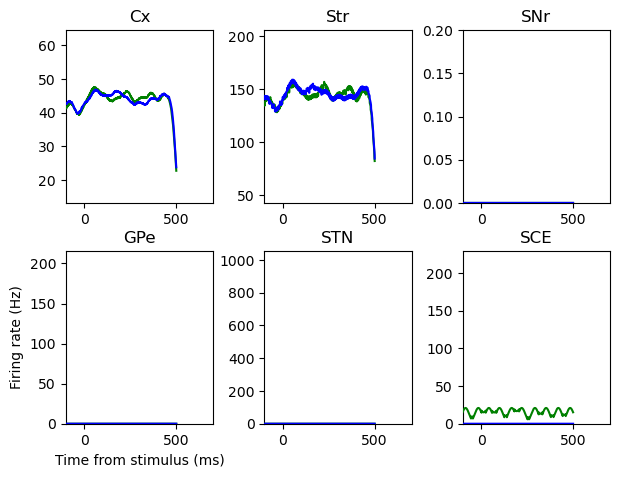

0.0
0.0


In [ ]:




class Model:
    def __init__(self, modelparams, clock, stimulus, T):
        #---------------------------------------------------------------------------------
        # Initialize
        #---------------------------------------------------------------------------------

        self.clock = clock
        self.T=T
        

        #---------------------------------------------------------------------------------
        # Complete the model specification
        #---------------------------------------------------------------------------------

        # Model parameters
        params = modelparams.copy()

        # Rescale conductances by number of neurons
        for x in ['gAMPA_E', 'gAMPA_I', 'gNMDA_E', 'gNMDA_I']:
            params['Cx'][x] /= params['Cx']['N_E']
        for x in ['gGABA_E', 'gGABA_I']:
            params['Cx'][x] /= params['Cx']['N_I']

        # Make local variables for convenience
        N_E   = params['Cx']['N_E']
        fsel  = params['Cx']['fsel']
        wp    = params['Cx']['wp']
        delay = params['Cx']['delay']
        alpha = params['Cx']['alpha']

        # Subpopulation size
        N1 = int(fsel*N_E)
        N2 = N1
        N0 = N_E - (N1 + N2)
        params['Cx']['N0'] = N0
        params['Cx']['N1'] = N1
        params['Cx']['N2'] = N2

        # Hebb-weakened weight
        wm = (1 - wp*fsel)/(1 - fsel)
        params['Cx']['wm'] = wm

        # Synaptic weights between populations
        self.W = np.asarray([
            [1,  1,  1],
            [wm, wp, wm],
            [wm, wm, wp]
            ])
        self.params = params
        self.delay = delay
        self.alpha = alpha
        #---------------------------------------------------------------------------------
        # Neuron populations
        #---------------------------------------------------------------------------------

        net      = OrderedDict() # Network objects
        netPJsub = OrderedDict() # Projection neuron subpopulations

        for x in ['E', 'I']:
            net['Cx'+x] = NeuronGroup(
                    params['Cx']['N_'+x],
                    model_equations[x],

                    threshold='V>Vth',
                    reset='V=Vreset',
                    refractory='tau_ref_'+x,
                    method='euler',
                    clock=clock,
                    namespace=params['Cx']
            )
        # Excitatory subpopulations
           # Excitatory subpopulations
        N0 = params['Cx']['N0']
        N1 = params['Cx']['N1']
        N2 = params['Cx']['N2']

        netPJsub['Cx0'] = net['CxE'][:N0]
        netPJsub['Cx1'] = net['CxE'][N0:N0+N1]
        netPJsub['Cx2'] = net['CxE'][N0+N1:N0+N1+N2]

        for x in ['Str', 'SNr', 'GPe', 'STN', 'SCE', 'SCI']:
            net[x] = NeuronGroup(
                params[x]['N_PJ'],
                model_equations[x],
                threshold='V > Vth',
                reset='V = Vreset',
                refractory=params[x]['tau_ref_PJ'],
                method='euler',
                clock=clock,
                namespace=params[x]
            )

            if x != 'SCI':
                half = params[x]['N_PJ'] // 2
                netPJsub[x + '1'] = net[x][:half]
                netPJsub[x + '2'] = net[x][half:]

        #---------------------------------------------------------------------------------
        # Background input (post-synaptic)
        #---------------------------------------------------------------------------------

        for x in ['E', 'I']:
            net['pg' + x] = PoissonGroup(
                params['Cx']['N_' + x],
                rates=params['Cx']['nu_ext'],
                clock=clock
            )

            net['ic' + x] = Synapses(
                net['pg' + x],
                net['Cx' + x],
                on_pre='sAMPA_ext += 1'
            )
            net['ic' + x].connect(j='i')
            net['ic' + x].delay = delay

        for x in ['Str', 'SNr', 'STN', 'SCE', 'SCI']:
            net['pg' + x] = PoissonGroup(
                params[x]['N_PJ'],
                rates=params[x]['nu_ext'],
                clock=clock
            )

        net['ic' + x] = Synapses(
            net['pg' + x],
            net[x],
            on_pre='sAMPA_ext += 1'
        )
        net['ic' + x].connect(j='i')
        net['ic' + x].delay = delay

        net['pgGPe_AMPA'] = PoissonGroup(
            params['GPe']['N_PJ'],
            rates=params['GPe']['nu_ext_AMPA'],
            clock=clock
        )
        net['icGPe_AMPA'] = Synapses(
            net['pgGPe_AMPA'],
            net['GPe'],
            on_pre='sAMPA_ext += 1'
        )
        net['icGPe_AMPA'].connect(j='i')
        net['icGPe_AMPA'].delay = delay

        net['pgGPe_GABA'] = PoissonGroup(
            params['GPe']['N_PJ'],
            rates=params['GPe']['nu_ext_GABA'],
            clock=clock
        )
        net['icGPe_GABA'] = Synapses(
            net['pgGPe_GABA'],
            net['GPe'],
            on_pre='sGABA_ext += 1'
        )
        net['icGPe_GABA'].connect(j='i')
        net['icGPe_GABA'].delay = delay

        #---------------------------------------------------------------------------------
        # Recurrent input
        #---------------------------------------------------------------------------------

        # Change pre-synaptic variables
        for x in ['CxI', 'Str', 'SNr', 'GPe', 'SCI']:
            net['icGABA_' + x] = Synapses(
                net[x],
                net[x],
                on_pre='sGABA += 1'
            )
            net['icGABA_' + x].connect(j='i')
            net['icGABA_' + x].delay = delay

        for x in ['CxE', 'STN']:
            net['icAMPA_NMDA_' + x] = Synapses(
                net[x],
                net[x],
                on_pre='''
                sAMPA += 1
                sNMDA += alpha*(1 - sNMDA)
                ''',
                namespace={'alpha': alpha}

            )
            net['icAMPA_NMDA_' + x].connect(j='i')
            net['icAMPA_NMDA_' + x].delay = delay

            # SCE
        alpha_F = params['SCE']['alpha_F']
        net['icNMDA_SCE'] = Synapses(
            net['SCE'],
            net['SCE'],
            on_pre='''
            sNMDA += alpha*(1 - sNMDA)
            F += alpha_F*(1 - F)
            ''',
            namespace={'alpha': alpha, 'alpha_F': alpha_F}
        )
        net['icNMDA_SCE'].connect(j='i')
        net['icNMDA_SCE'].delay = delay

        # sparse recurrent connection
        prob_GPe_GPe = 0.05
        prob_GPe_STN = 0.02  # GPe to STN
        prob_STN_GPe = 0.05  # STN to GPe

        N_PJ1 = params['GPe']['N_PJ'] // 2

        # here the seed 100 is choosed arbitarily
        rns = np.random.RandomState(100)

        conn_GPe_GPe = 1*(rns.random_sample((N_PJ1,N_PJ1))<prob_GPe_GPe)
        conn_GPe_STN = 1*(rns.random_sample((N_PJ1,N_PJ1))<prob_GPe_STN)
        conn_STN_GPe = 1*(rns.random_sample((N_PJ1,N_PJ1))<prob_STN_GPe)

        self.sconn_GPe_GPe = csr_matrix(conn_GPe_GPe)
        self.sconn_GPe_STN = csr_matrix(conn_GPe_STN)
        self.sconn_STN_GPe = csr_matrix(conn_STN_GPe)

        self.wGABA_GPe_SNr = params['SNr']['gGABA_GPe_SNr']/params['SNr']['gGABA_I']
        self.wGABA_GPe_GPe = params['GPe']['gGABA_GPe_GPe']/params['GPe']['gGABA_I']
        self.wNMDA_SCE_CxE = params['Cx']['gNMDA_SCE_CxE']/params['Cx']['gNMDA_E']
        self.wNMDA_SCE_CxI = params['Cx']['gNMDA_SCE_CxI']/params['Cx']['gNMDA_I']
        self.wGABA_SCI_SCE = params['SCE']['gGABA_SCI_SCE']/params['SCE']['gGABA_E']

        # Link pre-synaptic variables to post-synaptic variables
        @network_operation(when='start', clock=clock)
        def recurrent_input():
            SAMPA = {i: {} for i in ['1', '2']}
            SNMDA = {i: {} for i in ['1', '2']}
            SGABA = {i: {} for i in ['1', '2']}

            for x in ['Cx', 'STN']:
                for i in ['1', '2']:
                    SAMPA[i][x] = np.sum(self.netPJsub[x + i].sAMPA[:])
                    SNMDA[i][x] = np.sum(self.netPJsub[x + i].sNMDA[:])

            for x in ['Str', 'SNr', 'GPe']:
                for i in ['1', '2']:
                    SGABA[i][x] = np.sum(self.netPJsub[x + i].sGABA[:])

            for i in ['1', '2']:
                SNMDA[i]['SCE'] = np.sum(self.netPJsub['SCE' + i].sNMDA[:])

            SGABA['SCI'] = np.sum(self.net['SCI'].sGABA[:])

            SCx0_AMPA = np.sum(self.netPJsub['Cx0'].sAMPA[:])
            SCx0_NMDA = np.sum(self.netPJsub['Cx0'].sNMDA[:])

            #AMPA

            S = self.W.dot([SCx0_AMPA, SAMPA['1']['Cx'], SAMPA['2']['Cx']])
            for i in range(3):
                self.netPJsub['Cx'+str(i)].S_AMPA = S[i]
            self.net['CxI'].S_AMPA = S[0]

            # NMDA
            S = self.W.dot([SCx0_NMDA, SNMDA['1']['Cx'], SNMDA['2']['Cx']])
            for i in range(3):
                self.netPJsub['Cx'+str(i)].S_NMDA = S[i]
            self.net['CxI'].S_NMDA = S[0] + self.wNMDA_SCE_CxI*(SNMDA['1']['SCE']+SNMDA['2']['SCE'])

            # GABA
            S = np.sum(self.net['CxI'].sGABA[:])
            self.net['CxE'].S_GABA = S
            self.net['CxI'].S_GABA = S

            for i in ['1','2']:
                # For SCE -> SCI
                SNMDA[i]['SCE_F']=np.dot(
                    self.netPJsub['SCE'+i].F, 
                    self.netPJsub['SCE'+i].sNMDA
                )

                self.netPJsub['Cx'+i].S_NMDA += self.wNMDA_SCE_CxE*(SNMDA['1']['SCE']+SNMDA['2']['SCE'])

                # Str
                self.netPJsub['Str'+i].S_AMPA = SAMPA[i]['Cx']
                self.netPJsub['Str'+i].S_GABA = SGABA[i]['Str']

                # SNr
                self.netPJsub['SNr'+i].S_NMDA = SNMDA[i]['STN']
                self.netPJsub['SNr'+i].S_GABA = (
                    SGABA[i]['Str'] + self.wGABA_GPe_SNr*SGABA[i]['GPe']
                )

                # GPe
                self.netPJsub['GPe'+i].S_AMPA = self.sconn_STN_GPe.dot(
                    self.netPJsub['STN'+i].sAMPA
                )
                self.netPJsub['GPe'+i].S_NMDA = self.sconn_STN_GPe.dot(
                    self.netPJsub['STN'+i].sNMDA
                )
                self.netPJsub['GPe'+i].S_GABA =(
                    self.sconn_GPe_GPe.dot(
                    self.netPJsub['GPe'+i].sGABA)*self.wGABA_GPe_GPe + SGABA[i]['Str']
                )  
                # STN:
                self.netPJsub['STN'+i].S_GABA = self.sconn_GPe_STN.dot(
                    self.netPJsub['GPe'+i].sGABA
                    
                )

                # SC
                self.netPJsub['SCE'+i].S_AMPA = SAMPA[i]['Cx']
                self.netPJsub['SCE'+i].S_NMDA = SNMDA[i]['SCE']
                self.netPJsub['SCE'+i].S_GABA = SGABA[i]['SNr']+ self.wGABA_SCI_SCE*SGABA['SCI']
            self.net['SCI'].S_NMDA = SNMDA['1']['SCE_F']+SNMDA['2']['SCE_F']

        #---------------------------------------------------------------------------------
        # External input (post-synaptic)
        #---------------------------------------------------------------------------------
        stim1_ta, stim2_ta = stimulus.make_timed_arrays(clock.dt, self.T)
        for i, stim_ta in zip([1, 2], [stim1_ta, stim2_ta]):
            net['pg'+str(i)] = PoissonGroup(
                params['Cx']['N'+str(i)],
                rates='stim_ta(t)', 
                clock=clock,
                namespace={'stim_ta':stim_ta}
            )
            net['ic'+str(i)] = Synapses(
                net['pg'+str(i)], 
                netPJsub['Cx'+str(i)],
                on_pre='sAMPA_ext += 1'
            )
            net['ic'+str(i)].connect(j='i')
            net['ic'+str(i)].delay = delay


         #---------------------------------------------------------------------------------
        # Record rates
        #---------------------------------------------------------------------------------

        rates = OrderedDict()
        for x in netPJsub:
            rates[x] = PopulationRateMonitor(netPJsub[x])

        #---------------------------------------------------------------------------------
        # Setup
        #---------------------------------------------------------------------------------

        self.params   = params
        self.net      = net
        self.netPJsub = netPJsub
        self.rates    = rates
        self.recurrent_input = recurrent_input

    




    def reinit(self):
        
        # Randomly initialize membrane potentials
        for x in ['E', 'I']:
            vreset = self.params['Cx']['Vreset']
            vth = self.params['Cx']['Vth']
            n = self.params['Cx']['N_' + x]
            self.net['Cx' + x].V = np.random.uniform(
                vreset / volt, vth / volt, size=n) * volt

        for x in ['Str', 'SNr', 'GPe', 'STN', 'SCE', 'SCI']:
             vreset = self.params[x]['Vreset']
             vth = self.params[x]['Vth']
             n = self.params[x]['N_PJ']
             self.net[x].V = np.random.uniform(vreset / volt, vth / volt, size=n) * volt

        # Set synaptic variables to zero
        for i in ['CxE', 'STN']:
            for x in ['sAMPA_ext', 'sAMPA', 'sNMDA']:
                setattr(self.net[i], x, 0)

        for i in ['CxI', 'Str', 'SNr', 'SCI']:
            for x in ['sAMPA_ext', 'sGABA']:
                setattr(self.net[i], x, 0)

        for x in ['sAMPA_ext', 'sNMDA']:
            setattr(self.net['SCE'], x, 0)

        for x in ['sAMPA_ext', 'sGABA_ext', 'sGABA']:
            setattr(self.net['GPe'], x, 0)
        setattr(self.net['SCE'], 'F', 0)
        setattr(self.net['GPe'], 'h', 1)
        setattr(self.net['STN'], 'h', 1)
# Troubleshooting guards: fail early with a clear message if names were shadowed.
assert isinstance(modelparams, dict), (
    f"modelparams should be dict, got {type(modelparams)}. "
    "Likely cause: cell execution order or variable overwrite."
)
assert isinstance(model_equations, dict), (
    f"model_equations should be dict, got {type(model_equations)}. "
    "If this says brian2.equations, re-run the equations cell after imports."
)
print("modelparams keys:", modelparams.keys())
print("model_equations keys:", model_equations.keys())
#=========================================================================================
# Simulation
#=========================================================================================

class Simulation:
    def __init__(self, modelparams, stimparams, dt, T):
        self.dt= dt
        self.T=T
        self.clock=Clock(dt=dt)
        self.stimulus = Stimulus(
            stimparams['Ton'], 
            stimparams['Toff'],
            stimparams['mu0'], 
            stimparams['coh'])
        
        self.model = Model(modelparams, self.clock, self.stimulus,T)
        
        # Build an explicit Brian2 Network from the actual Brian objects
        objects = []

        # neuron groups, poisson groups, synapses, etc.
        objects.extend(list(self.model.net.values()))

        # monitors
        objects.extend(list(self.model.rates.values()))

        # network operation
        objects.append(self.model.recurrent_input)

        self.network = Network(*objects)


    def run(self, T=None, seed=1):
        if T is None:
            T=self.T
        # Initialize random number generators
        pyrand.seed(seed)
        np.random.seed(seed)

        # Initialize and run
        
        self.model.reinit()
        self.network.run(T,report='text')

    def saverates(self, filename, smooth=10*ms):
        time  = self.model.rates['Cx1'].t/ms
        rates = {}
        for name in ['Cx', 'Str', 'SNr', 'GPe', 'STN', 'SCE']:
            rates[name+'1'] = self.model.rates[name+'1'].smooth_rate(width=smooth)/Hz
            rates[name+'2'] = self.model.rates[name+'2'].smooth_rate(width=smooth)/Hz

        with open(filename, 'wb') as f:
            pkl.dump((time, rates), f,protocol=pkl.HIGHEST_PROTOCOL)

#/////////////////////////////////////////////////////////////////////////////////////////

if __name__ == '__main__':
    stimparams = dict(
        Ton  = 0.5*second, # Stimulus onset
        Toff = 1.5*second, # Stimulus offset
        mu0  = 40*Hz,      # Input rate
        coh  = 0           # Percent coherence
        )

    # Fast iteration mode while debugging/tuning.
    quick_mode = True
    if quick_mode:
        dt = 0.1*ms
        T = 1*second
        smooth_width = 20*ms
    else:
        dt = 0.05*ms
        T = 2*second
        smooth_width = 10*ms

    sim = Simulation(modelparams, stimparams, dt, T)
    sim.stimulus.set_coh(25.6) # Shows how coherence can be changed

    # For fast plotting iterations, reuse cached rates if available.
    rerun_simulation = False
    rates_file = 'rates.pkl'

    if rerun_simulation:
        sim.run(seed=10)
        sim.saverates(rates_file, smooth=smooth_width)

        print(np.mean(sim.model.net['STN'].I_T / pA), 'pA')
        print(np.mean(sim.model.net['STN'].Isyn / pA), 'pA')
    else:
        import os
        if not os.path.exists(rates_file):
            print('rates.pkl not found; running simulation once...')
            sim.run(seed=10)
            sim.saverates(rates_file, smooth=smooth_width)

    #-------------------------------------------------------------------------------------
    # Plot firing rates in different areas
    #-------------------------------------------------------------------------------------

    # Load firing rates
    with open(rates_file,'rb') as f:
        time, rates = pkl.load(f)

    # Align time to stimulus onset
    time -= stimparams['Ton']/ms

    import matplotlib.pyplot as plt

    w  = 0.23
    h  = 0.36
    dx = 0.08
    dy = 0.1
    x1 = 0.1
    x2 = x1+w+dx
    x3 = x2+w+dx
    y1 = 0.11
    y2 = y1+h+dy

    # Figure setup
    fig   = plt.figure()
    plots = {
        'GPe': fig.add_axes([x1, y1, w, h]),
        'STN': fig.add_axes([x2, y1, w, h]),
        'SCE': fig.add_axes([x3, y1, w, h]),
        'Cx':  fig.add_axes([x1, y2, w, h]),
        'Str': fig.add_axes([x2, y2, w, h]),
        'SNr': fig.add_axes([x3, y2, w, h])
        }
    for name, plot in plots.items():
        plot.set_title(name)
    plots['GPe'].set_xlabel('Time from stimulus (ms)')
    plots['GPe'].set_ylabel('Firing rate (Hz)')

    for name, plot in plots.items():
        plot.plot(time, rates[name+'1'], 'g', zorder=5)
        plot.plot(time, rates[name+'2'], 'b', zorder=5)
        plot.set_xlim(-100, 700)
        plot.set_xticks([0, 500])

    # Y-axis control:
    # - use_auto_ylim=True: auto-scale each panel from its own data
    # - use_auto_ylim=False: use defaults, with optional overrides below
    use_auto_ylim = True

    manual_ylims_default = {
        'Cx': (0, 20),
        'Str': (0, 35),
        'SNr': (0, 100),
        'GPe': (0, 100),
        'STN': (0, 100),
        'SCE': (0, 250),
    }

    # Optional manual per-panel overrides (uncomment/edit as needed)
    # manual_ylims_override = {
    #     'STN': (0, 40),
    #     'GPe': (10, 50),
    # }
    manual_ylims_override = {}

    if use_auto_ylim:
        y_zoom_pad = 0.1  # 10% headroom
        min_span = 2.0    # keep a minimum y-range in Hz
        for name, plot in plots.items():
            y1 = np.asarray(rates[name+'1'])
            y2 = np.asarray(rates[name+'2'])
            y = np.concatenate([y1, y2])
            y_min = float(np.min(y))
            y_max = float(np.max(y))
            span = max(y_max - y_min, min_span)
            pad = span * y_zoom_pad
            lower = max(0.0, y_min - pad)
            upper = y_max + pad
            plot.set_ylim(lower, upper)
    else:
        # Start from historical defaults, then apply any overrides.
        ylims = dict(manual_ylims_default)
        ylims.update(manual_ylims_override)
        for name, plot in plots.items():
            plot.set_ylim(*ylims[name])

    import os
    out_pdf = os.path.join(os.getcwd(), 'wei2015_side_by_side.pdf')
    print(f"Saving plot to {out_pdf}")
    plt.savefig(out_pdf, dpi=200, bbox_inches='tight')
    plt.show()


print(np.mean(sim.model.net['CxE'].V / mV))
print(np.max(sim.model.net['CxE'].V / mV))



# MAKE AXIS LONGER TO SEE MORE OF THE GRAPH 

Loaded rates from: /Users/andrearousing/Desktop/neuroscience kursus/Theoretical_Neuroscience/chapter06-basal-ganglia-thalamocortical-loop-model/rates.pkl


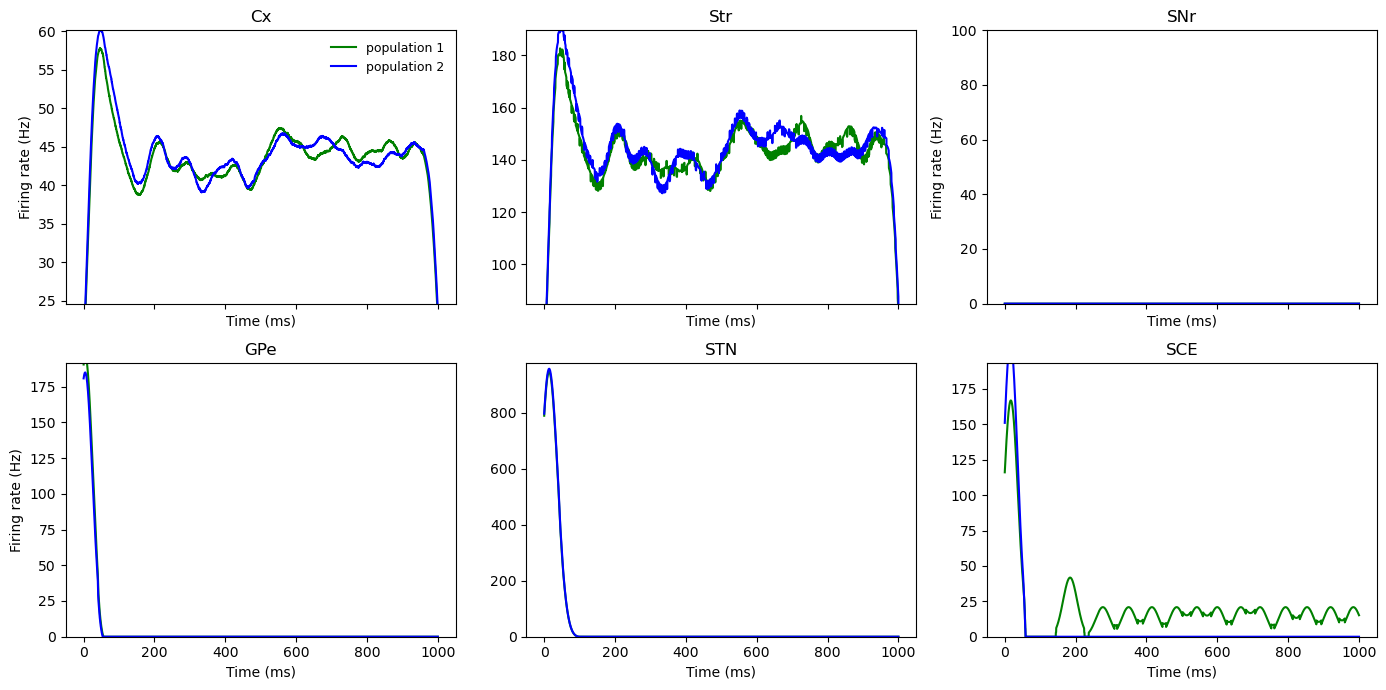

In [ ]:
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from brian2 import ms, Hz  # only used for unit conversions

# Load rates.pkl (expects to find it in or above the current working directory).
rates_path = None
for parent in [Path.cwd()] + list(Path.cwd().parents)[:10]:
    cand = parent / 'rates.pkl'
    if cand.exists():
        rates_path = cand
        break

if rates_path is None:
    raise FileNotFoundError('Could not find rates.pkl in the current directory tree.')

with open(rates_path, 'rb') as f:
    time, rates = pkl.load(f)

print(f"Loaded rates from: {rates_path.resolve()}")

areas = ['Cx', 'Str', 'SNr', 'GPe', 'STN', 'SCE']
color1, color2 = 'g', 'b'

# Convert to Brian2 quantities, then convert back to plain numbers for matplotlib.
t = np.asarray(time)
t_q = t * ms
t_plot = t_q / ms

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
axes = axes.flatten()

for ax, area in zip(axes, areas):
    k1, k2 = area + '1', area + '2'
    if k1 not in rates or k2 not in rates:
        ax.set_title(f"{area} (missing keys)")
        continue

    y1 = np.asarray(rates[k1])
    y2 = np.asarray(rates[k2])

    y1_q = y1 * Hz
    y2_q = y2 * Hz
    y1_plot = y1_q / Hz
    y2_plot = y2_q / Hz

    ax.plot(t_plot, y1_plot, color1, lw=1.5)
    ax.plot(t_plot, y2_plot, color2, lw=1.5)
    ax.set_title(area)
    ax.set_xlabel('Time (ms)')

    if area == 'SNr':
        ax.set_ylim(0, 100)
        ax.set_ylabel('Firing rate (Hz)')
    else:
        y = np.concatenate([y1, y2])
        lo = float(np.percentile(y, 1))
        hi = float(np.percentile(y, 99))
        if hi - lo < 1e-12:
            ax.set_ylim(0, 1)
        else:
            pad = 0.05 * (hi - lo)
            ax.set_ylim(max(0.0, lo - pad), hi + pad)

# y-labels for left column only
axes[0].set_ylabel('Firing rate (Hz)')
axes[3].set_ylabel('Firing rate (Hz)')

# Legend
axes[0].plot([], [], color=color1, label='population 1')
axes[0].plot([], [], color=color2, label='population 2')
axes[0].legend(loc='upper right', fontsize=9, frameon=False)

plt.tight_layout()
plt.show()
